In [1]:
import matplotlib.pyplot as plt
from tshap.synthetic import DoubleFreqTest
from tshap.tshap import tshap_explanation
from tshap.xutil import *

from aeon.datasets import load_classification
from aeon.transformations.collection.convolution_based import MiniRocket
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### Synthetic Data

In [2]:
synth_gen = DoubleFreqTest()

X_train,y_train, X_train_true_attribs = synth_gen.generate_classification_data_and_attribs(n_samples = 30, random_seed=0)
X_test, y_test, X_test_true_attribs = synth_gen.generate_classification_data_and_attribs(n_samples = 30, random_seed=1)


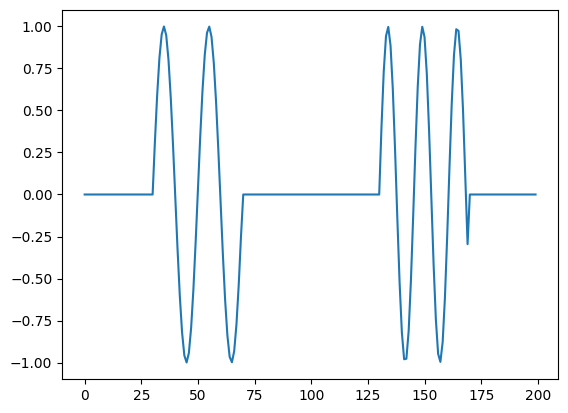

In [3]:
plt.figure
plt.plot(X_train[0,0,:])
plt.show()

In [3]:
# get the hypothetical model
clf = synth_gen.get_classification_model()

In [4]:
y_pred = clf.predict(X_test)
print('Classification Accuracy: ' + str(np.sum(y_test == y_pred) / len(y_test)))

Classification Accuracy: 1.0


In [5]:
tshap_window_attribs, tshap_roi_attribs = tshap_explanation(clf.decision_function, X_test, baselines=X_train)

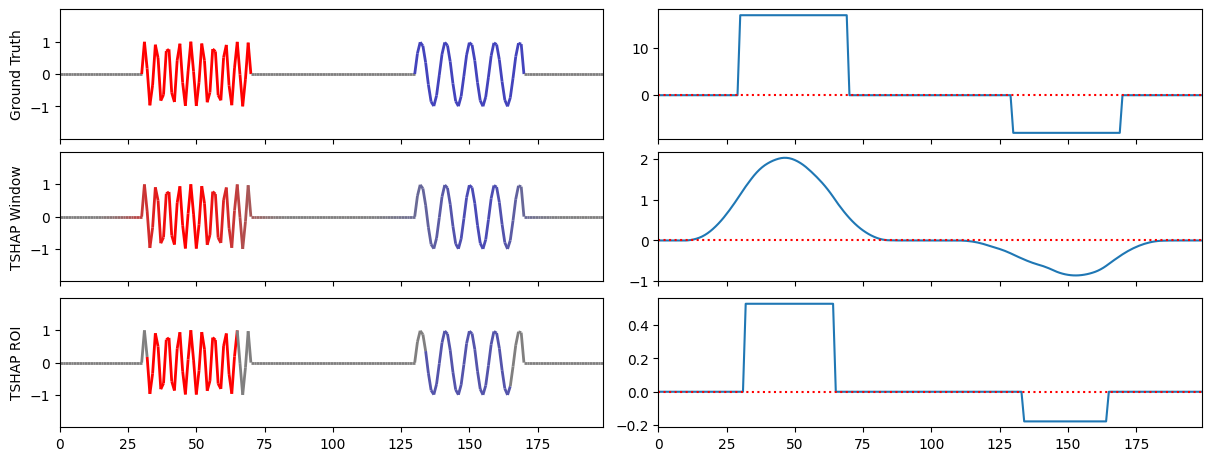

In [7]:
id = 0
sample = X_test[id,0,:]
attribs = [attr[id,0,:] for attr in [X_test_true_attribs, tshap_window_attribs, tshap_roi_attribs]]
plot_saliency_map_and_attributions(sample,attribs, ['Ground Truth', 'TSHAP Window', 'TSHAP ROI'])

### UCR Data

In [8]:
X_train, y_train = load_classification('Coffee',split='train')
X_test, y_test = load_classification('Coffee',split='test')

clf = make_pipeline(
            MiniRocket(random_state=42),
            StandardScaler(with_mean=False),
            LogisticRegression(), # replace the default RidgeCV with LogisticRegression to get the prediction probability
        ).fit(X_train,y_train)

In [9]:
tshap_window_attribs, tshap_roi_attribs = tshap_explanation(clf.predict_proba, X_test, baselines=X_train)

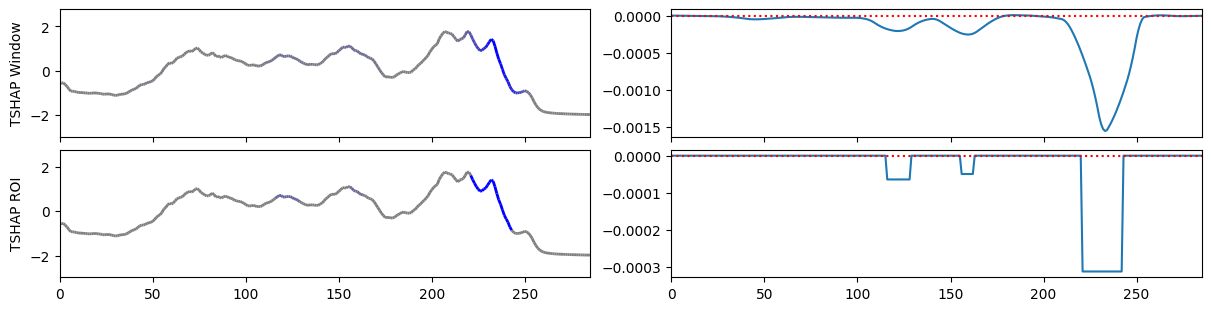

In [10]:
id = 1
sample = X_test[id,0,:]
attribs = [attr[id,0,:] for attr in [tshap_window_attribs, tshap_roi_attribs]]
plot_saliency_map_and_attributions(sample,attribs, ['TSHAP Window', 'TSHAP ROI'])

In [15]:
tshap_roi_attribs.shape

(28, 1, 286)